# Assignment 1: Classify Breast Cancer Cases

Author: Tobias Beekmans  
Master ICT – Software Engineering  
DataOps Specialisation Project – Individual Assignment  
Submission Date: 15.03.2026

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.stats import pointbiserialr
from breast_cancer_assignment.dataset import load_data

# Notebook settings
pd.set_option('display.max_columns', None)

# Load dataset
df = load_data()

# 2.0 Data Understanding

## 2.1 Data Sources and Collection

The dataset used in this project is the Breast Cancer Wisconsin (Diagnostic) dataset from the UCI Machine Learning Repository [1]. It contains diagnostic measurements derived from digitized images of fine needle aspirate (FNA) samples of breast masses.

Within this project, the data is managed in two local forms:

- original raw dataset: data/raw/dataset.csv
- processed dataset generated through the project workflow: data/processed/dataset.csv

To ensure reproducibility and consistency across notebooks, the dataset is loaded through the project function `load_data()`, which provides a standardised access point for the data used in the analysis.

In [369]:
df = load_data()

## 2.2 Dataset Description

The dataset used in this project is the Breast Cancer Wisconsin (Diagnostic) dataset from the UCI Machine Learning Repository [1].

The dataset contains features extracted from digitized images of fine needle aspirate (FNA) samples of breast masses. These features describe morphological characteristics of the cell nuclei present in the images and are commonly used for diagnostic classification tasks. The features represent ten core characteristics of the cell nuclei [1]:

- radius
- texture
- perimeter
- area
- smoothness
- compactness
- concavity
- concave points
- symmetry
- fractal dimension

For each of these characteristics, three measurements are provided:

- mean value
- standard error
- worst value

These measurements capture both the typical properties of the nuclei and variations within the tumour sample.

The dataset also contains a diagnostic label indicating whether the tumour is malignant or benign, which serves as the target variable for the classification task.

The following analysis inspects the dataset structure by examining its dimensions, column data types, and sample data.

### Table Dimensions

The dimensions of the dataset are inspected to understand the number of records and variables.

In [370]:
rows, columns = df.shape
print(f"Rows: {rows}")
print(f"Columns: {columns}")

Rows: 569
Columns: 31


The dataset contains 569 records and 31 columns in total.

### Data Types

The following output shows the data type of each column.

In [371]:
print(df.dtypes.value_counts())
df.dtypes

float64    30
int64       1
Name: count, dtype: int64


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

All variables are numerical. The dataset also contains one target variable that represents the class label used for classification. According to the dataset documentation [1], the encoding is defined as:

- 0 = malignant tumour
- 1 = benign tumour

This variable will later be used as the prediction target for the machine learning models.

### Sample Data

To gain an initial understanding of the dataset, a small sample of observations is displayed.

In [372]:
df.sample(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
478,11.49,14.59,73.99,404.9,0.10460,0.08228,0.05308,0.01969,0.1779,0.06574,0.2034,1.1660,1.567,14.34,0.004957,0.02114,0.04156,0.008038,0.01843,0.003614,12.40,21.90,82.04,467.6,0.1352,0.2010,0.2596,0.07431,0.2941,0.09180,1
84,12.00,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,0.2271,1.2550,1.441,16.16,0.005969,0.01812,0.02007,0.007027,0.01972,0.002607,13.67,24.90,87.78,567.9,0.1377,0.2003,0.2267,0.07632,0.3379,0.07924,1
14,13.73,22.61,93.60,578.3,0.11310,0.22930,0.21280,0.08025,0.2069,0.07682,0.2121,1.1690,2.061,19.21,0.006429,0.05936,0.05501,0.016280,0.01961,0.008093,15.03,32.01,108.80,697.7,0.1651,0.7725,0.6943,0.22080,0.3596,0.14310,0
30,18.63,25.11,124.80,1088.0,0.10640,0.18870,0.23190,0.12440,0.2183,0.06197,0.8307,1.4660,5.574,105.00,0.006248,0.03374,0.05196,0.011580,0.02007,0.004560,23.15,34.01,160.50,1670.0,0.1491,0.4257,0.6133,0.18480,0.3444,0.09782,0
115,11.93,21.53,76.53,438.6,0.09768,0.07849,0.03328,0.02008,0.1688,0.06194,0.3118,0.9227,2.000,24.79,0.007803,0.02507,0.01835,0.007711,0.01278,0.003856,13.67,26.15,87.54,583.0,0.1500,0.2399,0.1503,0.07247,0.2438,0.08541,1
210,20.58,22.14,134.70,1290.0,0.09090,0.13480,0.16400,0.09561,0.1765,0.05024,0.8601,1.4800,7.029,111.70,0.008124,0.03611,0.05489,0.027650,0.03176,0.002365,23.24,27.84,158.30,1656.0,0.1178,0.2920,0.3861,0.19200,0.2909,0.05865,0
23,21.16,23.04,137.20,1404.0,0.09428,0.10220,0.10970,0.08632,0.1769,0.05278,0.6917,1.1270,4.303,93.99,0.004728,0.01259,0.01715,0.010380,0.01083,0.001987,29.17,35.59,188.00,2615.0,0.1401,0.2600,0.3155,0.20090,0.2822,0.07526,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,0.2976,1.5990,2.039,23.94,0.007149,0.07217,0.07743,0.014320,0.01789,0.010080,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,0
498,18.49,17.52,121.30,1068.0,0.10120,0.13170,0.14910,0.09183,0.1832,0.06697,0.7923,1.0450,4.851,95.77,0.007974,0.03214,0.04435,0.015730,0.01617,0.005255,22.75,22.88,146.40,1600.0,0.1412,0.3089,0.3533,0.16630,0.2510,0.09445,0
338,10.05,17.53,64.41,310.8,0.10070,0.07326,0.02511,0.01775,0.1890,0.06331,0.2619,2.0150,1.778,16.85,0.007803,0.01449,0.01690,0.008043,0.02100,0.002778,11.16,26.84,71.98,384.0,0.1402,0.1402,0.1055,0.06499,0.2894,0.07664,1


The sample shows that each observation contains numerical measurements describing cell properties, together with a target variable indicating whether the tumour is malignant or benign.

## 2.3 Data Structure Overview

This section examines the statistical properties of the dataset features.  
Descriptive statistics help to understand the scale, distribution, and variability of the numerical variables before further analysis and modelling steps.

The first overview is generated using the standard `describe()` function in pandas, which provides key statistics for each numerical feature, including the mean, standard deviation, minimum, maximum, and quartile values.

### Summary Statistics

Basic statistical measures are calculated to understand the range, central tendency, and spread of the numerical variables.

In [373]:
df.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,0.41,1.22,2.87,40.34,0.01,0.03,0.03,0.01,0.02,0.00,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,0.28,0.55,2.02,45.49,0.00,0.02,0.03,0.01,0.01,0.00,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,0.11,0.36,0.76,6.80,0.00,0.00,0.00,0.00,0.01,0.00,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,0.23,0.83,1.61,17.85,0.01,0.01,0.02,0.01,0.02,0.00,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,0.32,1.11,2.29,24.53,0.01,0.02,0.03,0.01,0.02,0.00,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,0.48,1.47,3.36,45.19,0.01,0.03,0.04,0.01,0.02,0.00,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,2.87,4.88,21.98,542.20,0.03,0.14,0.40,0.05,0.08,0.03,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


The summary statistics show that the dataset contains numerical variables with varying scales and ranges.

Some features such as `area_mean` and `perimeter_mean` have much larger values compared to variables such as `smoothness_mean` or `fractal_dimension_mean`.  
This indicates that feature scaling may be necessary before training certain machine learning models.

In addition, the presence of large differences between minimum and maximum values suggests that some features may contain potential outliers, which will be investigated further in the data quality analysis.

### Additional Statistical Metrics

Additional statistical metrics are calculated to further examine the distribution and variability of the numerical features.

These metrics provide complementary information to the summary statistics and help identify potential asymmetries or dispersion patterns within the dataset.

In [374]:
median = df.median(numeric_only=True)
variance = df.var(numeric_only=True)
skew = df.skew(numeric_only=True)
kurt = df.kurtosis(numeric_only=True)
iqr = df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True)

stats = pd.DataFrame({
    'median': median,
    'variance': variance,
    'skewness': skew,
    'kurtosis': kurt,
    'IQR': iqr
})

stats.round(2)

,median,variance,skewness,kurtosis,IQR
mean radius,13.37,12.42,0.94,0.85,4.08
mean texture,18.84,18.50,0.65,0.76,5.63
mean perimeter,86.24,590.44,0.99,0.97,28.93
mean area,551.10,123843.55,1.65,3.65,362.40
mean smoothness,0.10,0.00,0.46,0.86,0.02
mean compactness,0.09,0.00,1.19,1.65,0.07
mean concavity,0.06,0.01,1.40,2.00,0.10
mean concave points,0.03,0.00,1.17,1.07,0.05
mean symmetry,0.18,0.00,0.73,1.29,0.03
mean fractal dimension,0.06,0.00,1.30,3.01,0.01


The additional statistical metrics provide further insight into the distribution characteristics of the dataset.

Several variables exhibit noticeable skewness, indicating that their distributions are not perfectly symmetric.  
This suggests that some features may contain long-tailed distributions or extreme values.

The interquartile range (IQR) highlights differences in variability between features, which may influence model behaviour and should be considered during later preprocessing steps such as scaling or feature transformation.

## 2.4 Data Quality Verification

Before proceeding to further analysis and modelling, the dataset is examined for potential data quality issues.

Typical data quality problems include missing values, duplicate records, invalid values, and extreme outliers. Identifying such issues early is important to ensure that the dataset is suitable for machine learning tasks and that model results are not distorted by data errors.

### Missing Values

The dataset is checked for missing values to ensure that all observations contain complete feature information.

In [375]:
missing_values = df.isna().sum()
missing_values_percent = df.isna().mean() * 100

missing_values_df = pd.DataFrame({
    'Missing Values [abs]': missing_values,
    'Missing Values [%]': missing_values_percent
})

print(f"Total missing values: {missing_values.sum()}")
missing_values_df.round(2)

Total missing values: 0


,Missing Values [abs],Missing Values [%]
mean radius,0,0.0
mean texture,0,0.0
mean perimeter,0,0.0
mean area,0,0.0
mean smoothness,0,0.0
mean compactness,0,0.0
mean concavity,0,0.0
mean concave points,0,0.0
mean symmetry,0,0.0
mean fractal dimension,0,0.0


The inspection shows that the dataset does not contain missing values.  
All observations have complete feature information, meaning no imputation or removal of records is required.

### Duplicates

Duplicate observations are checked to ensure that the dataset does not contain repeated entries that could bias the model training.

In [376]:
duplicates = df.duplicated().sum()
print(f"Total Duplicates: {duplicates}")

Total Duplicates: 0


The dataset does not contain duplicate records.  
Each observation therefore represents a unique sample.

### Invalid Values

The dataset is examined for potential invalid values, such as negative values in features where negative measurements would not be meaningful.

In [377]:
negatives = (df.select_dtypes(include='number') < 0).any()
neg_columns = negatives[negatives].index.tolist()
print(f"Columns with negative values: {neg_columns if neg_columns else 'None'}")

Columns with negative values: None


No invalid negative values were detected in the dataset.  
All feature values appear to fall within reasonable numerical ranges.

### Outlier Detection

Outliers are examined to identify extreme values that may influence model training.

Two common statistical methods are used to identify potential extreme values:

- Interquartile Range (IQR): identifies values outside the typical distribution range
- Z-score: detects observations that are several standard deviations away from the mean

These methods help identify features that may contain extreme observations. However, in medical datasets such values may reflect genuine biological variation rather than data errors.

In [378]:
numeric_columns = df.select_dtypes(include='number').columns.drop('target')

# IQR Outlier Count
iqr_outliers = {}
for col in numeric_columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_outliers[col] = ((df[col] < lower) | (df[col] > upper)).sum()
iqr_outliers = pd.Series(iqr_outliers)

# Z-Score Outlier Count
z_scores = df[numeric_columns].apply(zscore)
z_outliers = (abs(z_scores) > 3).sum()

# Compare
outlier_compare = pd.DataFrame({
    'Z-Score Outliers': z_outliers,
    'IQR Outliers': iqr_outliers
})

outlier_compare.sort_values('IQR Outliers', ascending=False).head(10)

,Z-Score Outliers,IQR Outliers
area error,6,65
radius error,7,38
perimeter error,8,38
worst area,10,35
smoothness error,7,30
compactness error,12,28
fractal dimension error,10,28
symmetry error,11,27
mean area,8,25
worst fractal dimension,9,24


The outlier analysis indicates that several features contain observations that fall outside typical statistical ranges.

Such values may reflect natural biological variability in tumour cell structures rather than measurement errors. Therefore, outliers will not be removed at this stage but will be considered during later preprocessing steps.

If necessary, robust scaling techniques or model types that are less sensitive to extreme values may be used.

## 2.5 Data Exploration

This section explores relationships and patterns within the dataset in order to better understand the behaviour of the features and their connection to the target variable.

The analysis focuses on the distribution of the target variable, correlations between features, and how individual features differ between malignant and benign tumour cases.

### 2.5.1 Target Distribution

The distribution of the target variable is examined to determine whether the dataset is balanced between malignant and benign tumour cases.

Class imbalance can affect model performance and evaluation metrics.

target_label
Benign       357
Malignant    212
Name: count, dtype: int64


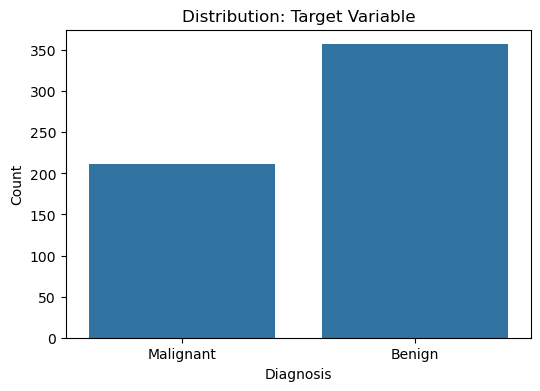

In [379]:
df['target_label'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

target_counts = df['target_label'].value_counts()
print(target_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='target_label', data=df)
plt.title('Distribution: Target Variable')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

The distribution shows that benign cases occur more frequently than malignant cases in the dataset. Although the classes are not perfectly balanced, the imbalance is moderate and both classes are sufficiently represented.

This is important for model training, as extremely imbalanced datasets can lead to biased models that favour the majority class. In this dataset, the class distribution is still suitable for standard classification techniques, though evaluation metrics such as recall and precision remain important.

### 2.5.2 Feature Correlation

A correlation matrix is calculated to examine relationships between the numerical features.

Highly correlated variables may capture similar information about tumour morphology. Such redundancy can influence certain machine learning algorithms, particularly linear models and distance-based methods, and may later motivate feature selection or regularisation.

#### Correlation Heatmap

The correlation heatmap visualises pairwise relationships between all numerical features.

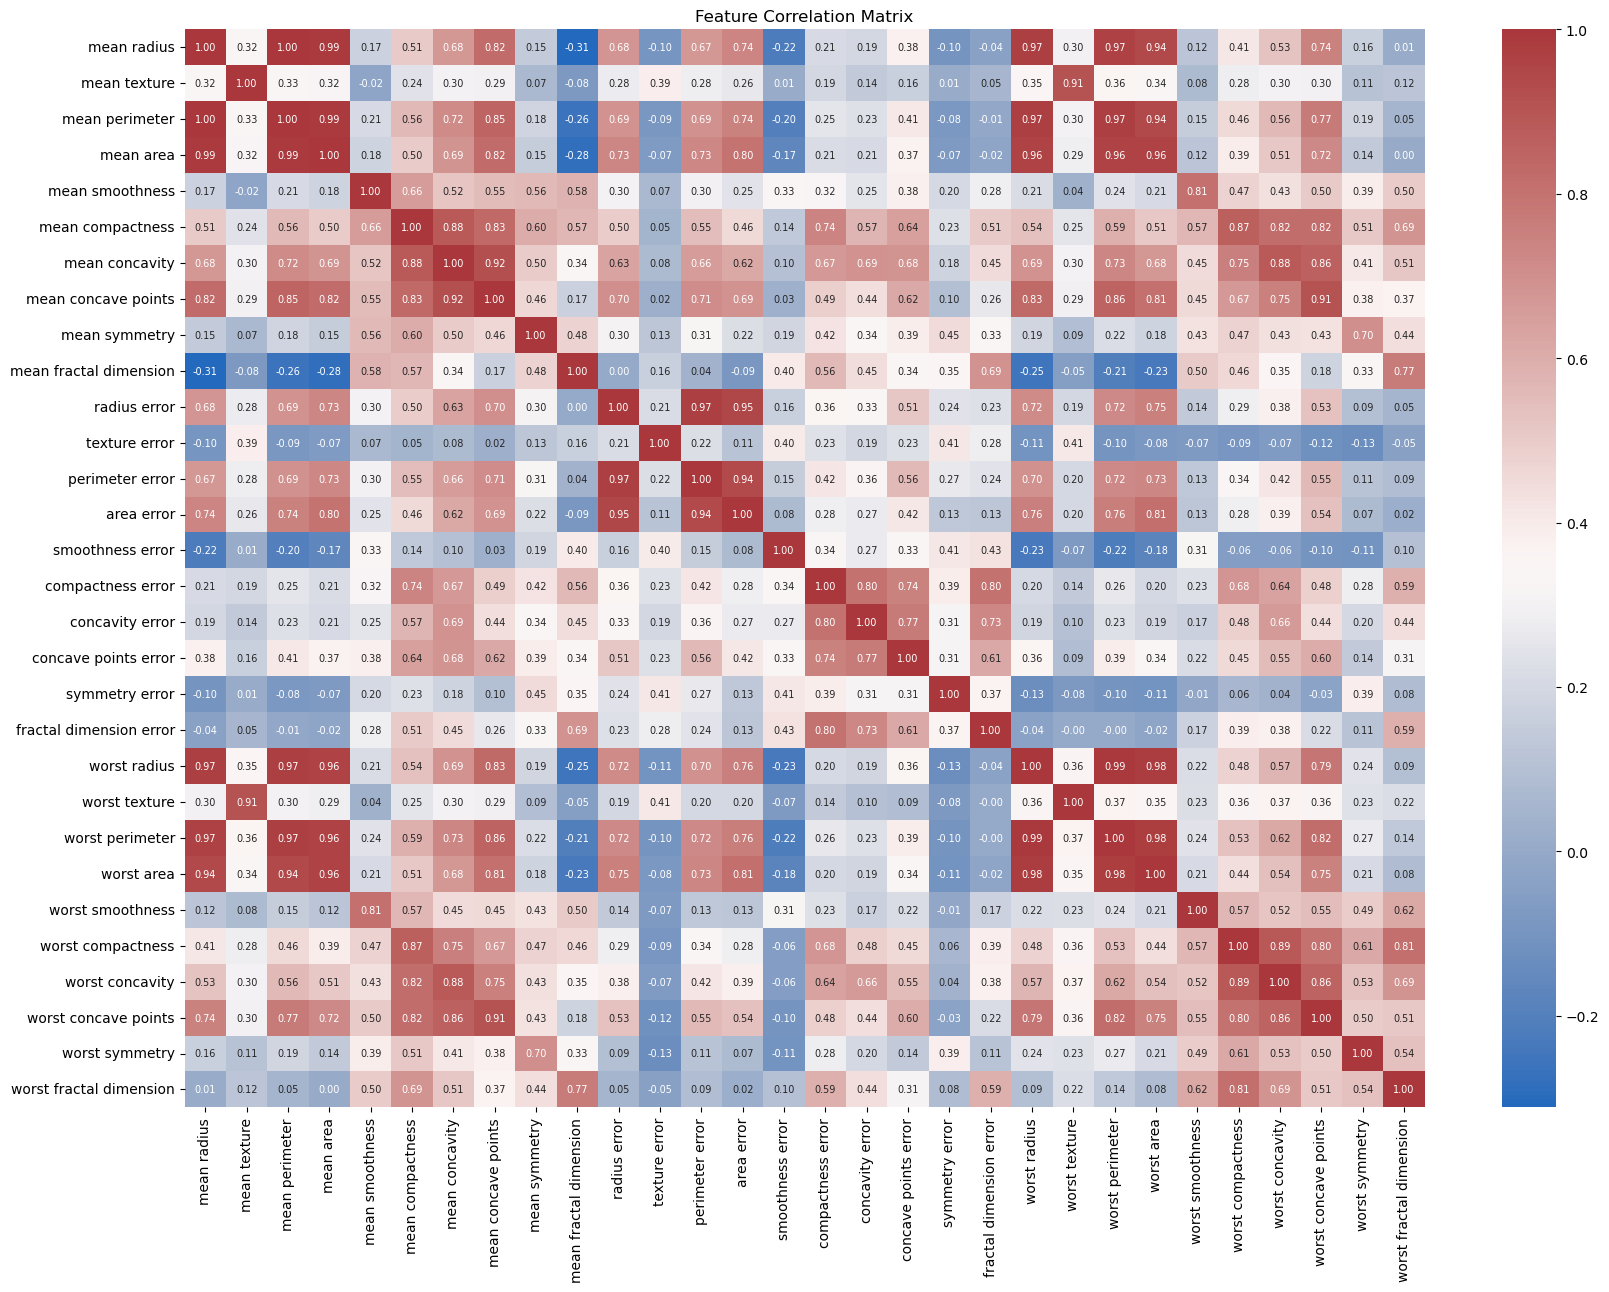

In [380]:
df_numeric = df.select_dtypes(include="number").drop(columns=["target"])

plt.figure(figsize=(20,14))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='vlag', annot_kws={"size": 7})
plt.title('Feature Correlation Matrix')
plt.show()

The heatmap reveals several strong correlations between groups of variables.

This is expected because multiple features describe related geometric properties of cell nuclei. For example, measurements such as radius, perimeter, and area naturally increase together and therefore show strong positive correlations.

The presence of strong correlations suggests that some features may contain overlapping information.

#### Highly Correlated Feature Pairs

To further examine feature redundancy, pairs of variables with very high absolute correlation values are identified.

In [381]:
corr_matrix = df_numeric.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle.stack()
    .sort_values(ascending=False)
    .reset_index()
)

high_corr_pairs.columns = ["Feature 1", "Feature 2", "Absolute Correlation"]

high_corr_pairs[high_corr_pairs["Absolute Correlation"] > 0.90].head(10)

,Feature 1,Feature 2,Absolute Correlation
0,mean radius,mean perimeter,0.997855
1,worst radius,worst perimeter,0.993708
2,mean radius,mean area,0.987357
3,mean perimeter,mean area,0.986507
4,worst radius,worst area,0.984015
5,worst perimeter,worst area,0.977578
6,radius error,perimeter error,0.972794
7,mean perimeter,worst perimeter,0.970387
8,mean radius,worst radius,0.969539
9,mean perimeter,worst radius,0.969476


The results confirm that several feature pairs exhibit very high correlation values.

This indicates that the dataset contains substantial feature redundancy. Such redundancy is expected because the dataset includes multiple measurements (mean, standard error, and worst values) for related morphological characteristics of the tumour cells.

These observations will be considered during later modelling stages, where feature selection or regularisation techniques may help reduce redundancy and improve model stability.

### 2.5.3 Feature–Target Association

To examine how strongly individual features are associated with the diagnostic outcome, the relationship between each numerical feature and the target variable is analysed.

Because the target variable represents a binary class label (malignant vs. benign), a standard Pearson correlation is not strictly appropriate. Instead, the point-biserial correlation coefficient is used. This statistic measures the relationship between a continuous variable and a binary variable and can therefore be interpreted as a special case of Pearson correlation adapted for binary classification problems.

Features with higher absolute point-biserial correlation values indicate stronger statistical association with the tumour diagnosis.

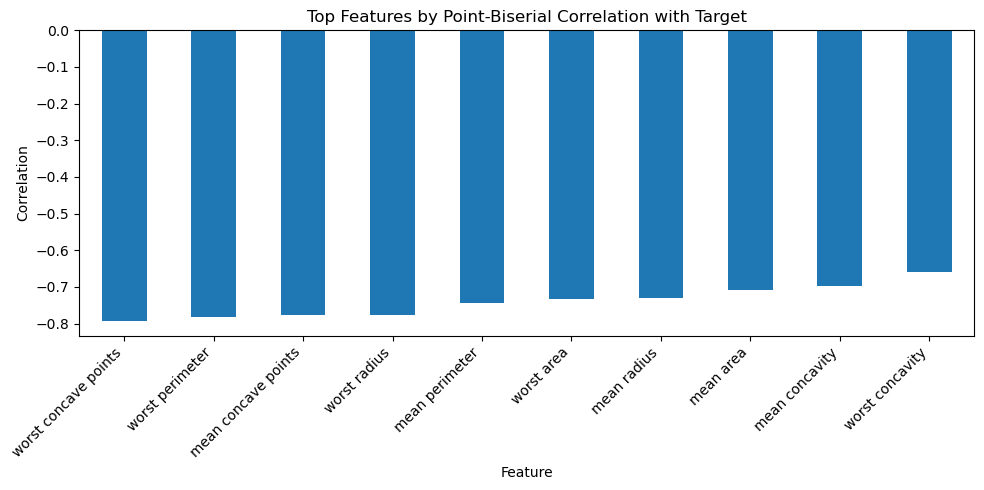

In [382]:
feature_columns = df.select_dtypes(include='number').columns.drop('target')

# Correlation
pb_corr = {}

for col in feature_columns:
    corr, _ = pointbiserialr(df[col], df['target'])
    pb_corr[col] = corr

corr_target = pd.Series(pb_corr).sort_values(key=lambda x: x.abs(), ascending=False)

# Plot
plt.figure(figsize=(10, 5))
corr_target.head(10).plot(kind='bar')
plt.title('Top Features by Point-Biserial Correlation with Target')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The analysis shows that several features exhibit strong statistical association with the tumour diagnosis.

In particular, measurements related to tumour size and shape, such as radius, perimeter, and area, appear to have strong relationships with the target variable. This suggests that these features may be highly informative for distinguishing malignant and benign tumour cases.

These results support the suitability of the dataset for machine learning classification tasks and help identify variables that may contribute significantly to model performance.

### 2.5.4 Feature Distribution Analysis

To further understand how features differ between malignant and benign tumours, the distributions of the most strongly correlated features were selected for visualization using boxplots and density plots.

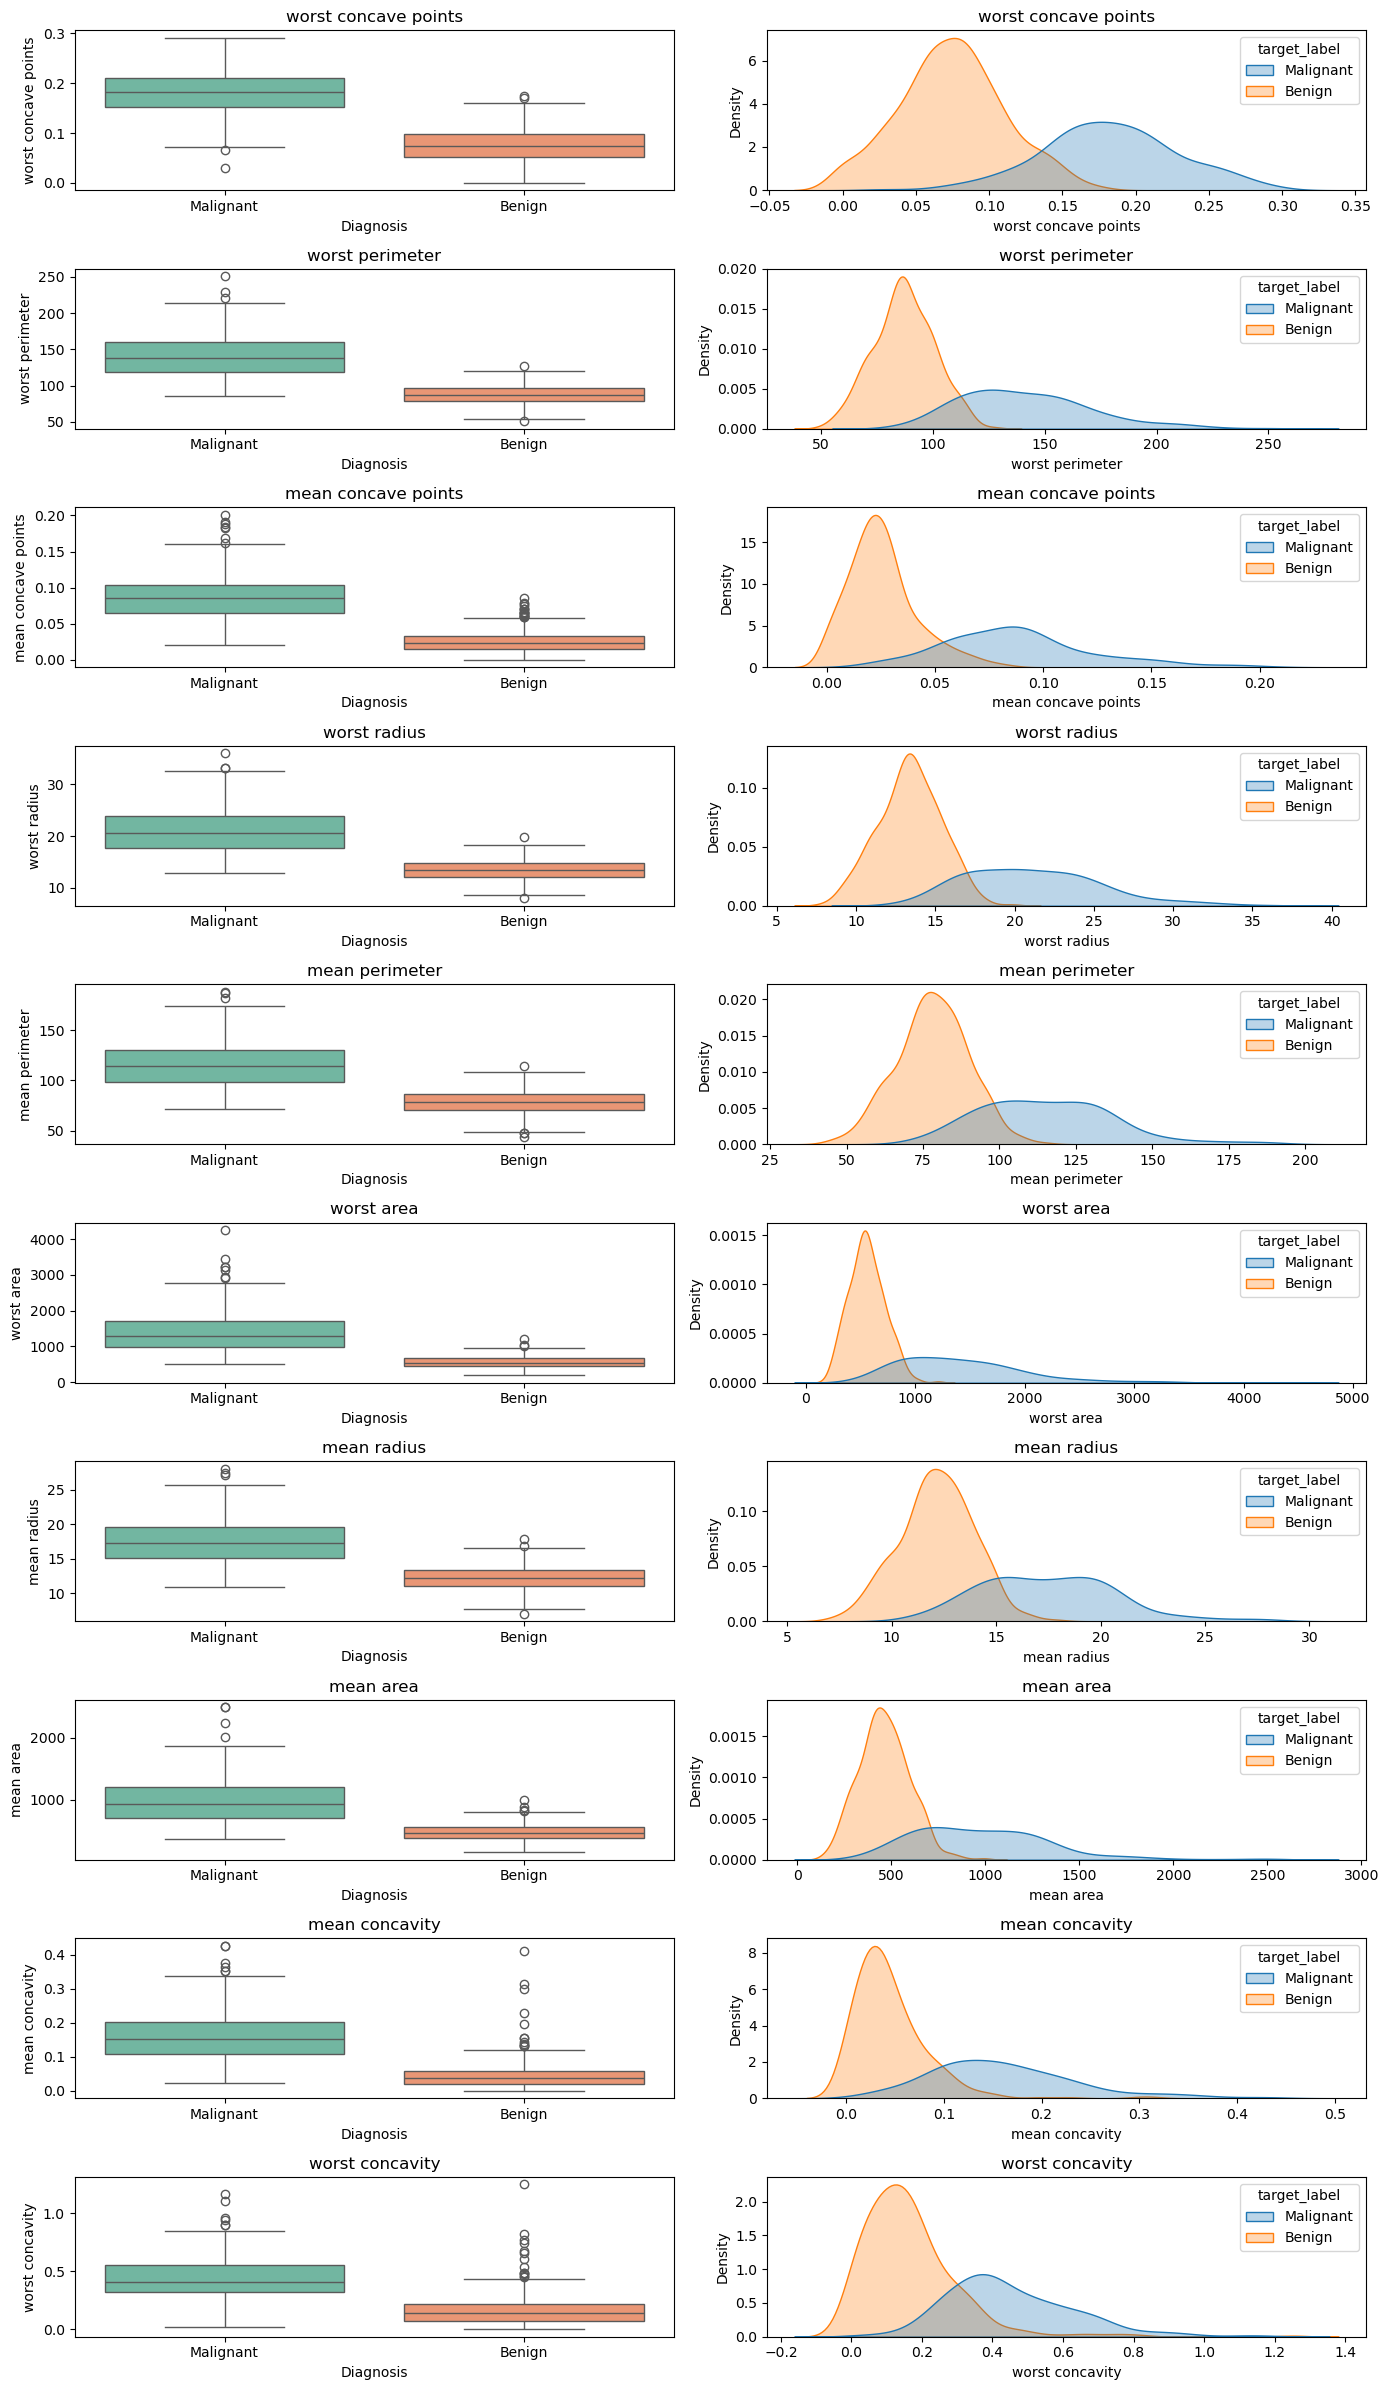

In [383]:
top_features = corr_target.head(10).index.tolist()
n = len(top_features)

fig, axes = plt.subplots(n, 2, figsize=(14, 2.4 * n))
axes = np.atleast_2d(axes)

for i, feat in enumerate(top_features):
    sns.boxplot(
        data=df,
        x="target_label",
        y=feat,
        hue="target_label",
        palette="Set2",
        legend=False,
        ax=axes[i, 0],
    )
    axes[i, 0].set_title(feat)
    axes[i, 0].set_xlabel("Diagnosis")
    axes[i, 0].set_ylabel(feat)

    sns.kdeplot(
        data=df,
        x=feat,
        hue="target_label",
        fill=True,
        alpha=0.3,
        ax=axes[i, 1],
    )
    axes[i, 1].set_title(feat)
    axes[i, 1].set_xlabel(feat)
    axes[i, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

The visualisations show that several features exhibit clear differences between malignant and benign tumour cases.

In many cases, malignant tumours tend to have larger values for size-related measurements such as radius, perimeter, and area. The distributions also appear to be more spread out for malignant cases, indicating greater variability.

These differences suggest that the extracted morphological features contain meaningful information for distinguishing between tumour types, supporting the suitability of the dataset for classification tasks.

## 2.6 Key Observations

The data understanding phase provides several important insights into the structure and characteristics of the dataset.

First, the dataset is complete and well-structured. No missing values or duplicate records were detected, and all predictor variables are numerical. This simplifies the preprocessing stage because no data imputation or record removal is required.

Second, the statistical analysis shows that the features vary considerably in scale and distribution. Some variables, such as measurements related to tumour size, have much larger numerical ranges than others. This indicates that feature scaling may be necessary for certain machine learning algorithms.

Third, the exploratory analysis reveals that several features are strongly correlated with each other. This confirms that the dataset contains a degree of feature redundancy, which is expected because multiple measurements describe related morphological characteristics of the tumour cells.

Finally, several features related to tumour size and shape exhibit strong association with the diagnostic label. This suggests that the extracted morphological measurements contain meaningful information for distinguishing malignant from benign tumour cases.

Overall, the dataset appears suitable for machine learning classification tasks. However, the next phase of the CRISP-DM process will need to address feature scaling and consider the potential impact of correlated variables during model development.